# Exploratory Data Analysis

In this notebook, we explore the AI4I 2020 Predictive Maintenance Dataset
to understand the data and identify patterns that could help us predict
machine failures.

## What we will look at

- Dataset structure and data types
- Missing values and duplicates
- Machine failure distribution
- Feature distributions and outliers
- Relationships between features and machine failures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the raw dataset
df = pd.read_csv("../data/raw/ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
df.shape

(10000, 14)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [4]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## Data Quality Checks

Before exploring the feature distributions, we check for duplicate
rows and inspect the categorical columns.

In [5]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [6]:
# Check the categorical columns
print("Type values:")
print(df["Type"].value_counts())

print("\nProduct ID examples:")
print(df["Product ID"].head(10))

Type values:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Product ID examples:
0    M14860
1    L47181
2    L47182
3    L47183
4    L47184
5    M14865
6    L47186
7    L47187
8    M14868
9    M14869
Name: Product ID, dtype: str


In [7]:
# Check the target distribution
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [8]:
# Target distribution as percentages
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

## Target Distribution

Most machines do not fail, so the target is highly imbalanced.

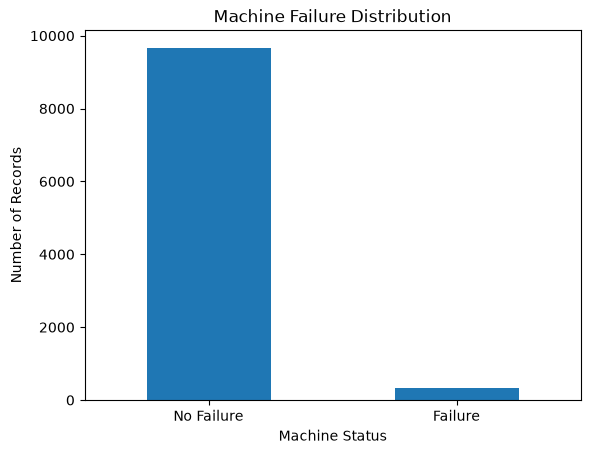

In [10]:
failure_counts = df["Machine failure"].value_counts()
failure_counts.index = ["No Failure", "Failure"]
failure_counts.plot(kind="bar")

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

## Feature Distributions

Next, we look at the main machine measurements to see how their values are distributed.

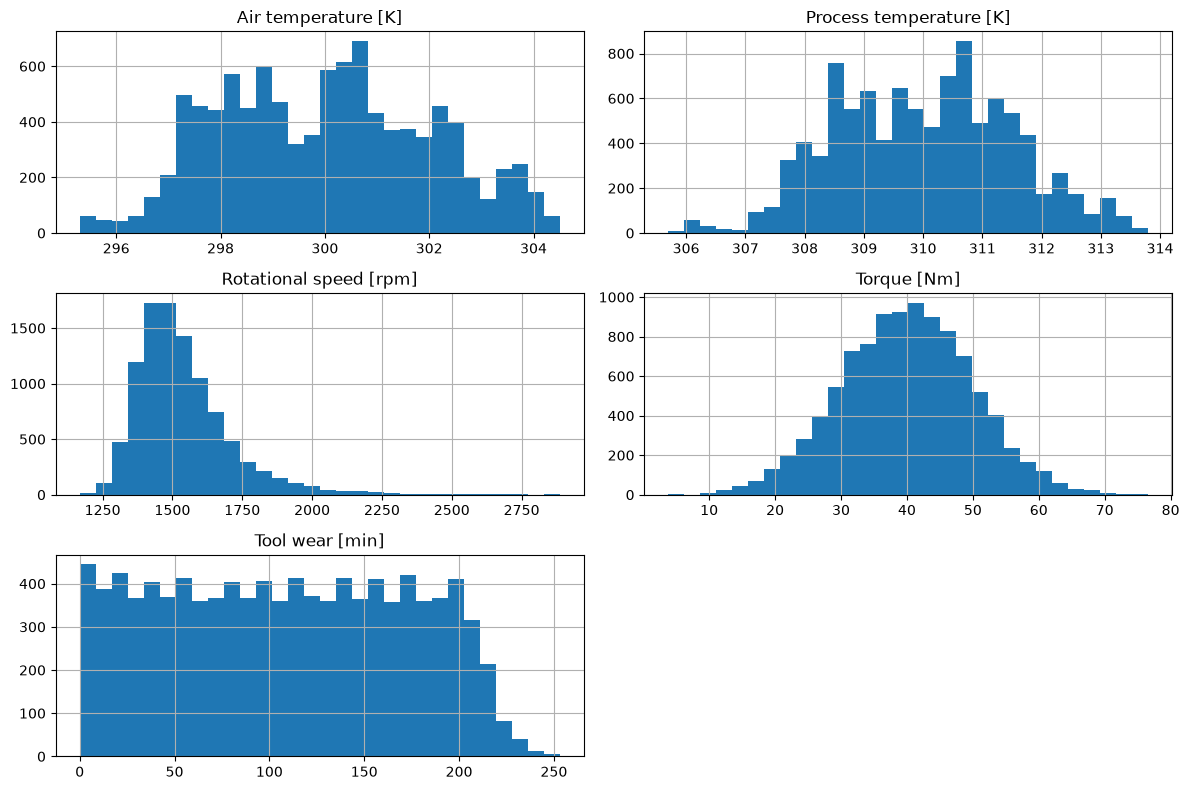

In [11]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[features].hist(figsize=(12, 8), bins=30)

plt.tight_layout()
plt.show()

## Features and Machine Failure

Let's compare the main machine measurements for machines that failed and those that did not.

In [12]:
failure_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df.groupby("Machine failure")[failure_features].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


## Failure Types

The dataset also includes information about the different types of machine failures. Let's see how often each failure type occurs.

In [16]:
failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]

df[failure_types].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

### Failure Type Distribution

HDF is the most common failure type in the dataset, followed by OSF and PWF. TWF and RNF occur less frequently.

## Correlation Analysis

We use correlation to see how the numerical features are related to machine failure and to each other.

In [18]:
corr = df.corr(numeric_only=True)

corr["Machine failure"].sort_values(ascending=False)

Machine failure            1.000000
HDF                        0.575800
OSF                        0.531083
PWF                        0.522812
TWF                        0.362904
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
RNF                        0.004516
UDI                       -0.022892
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64

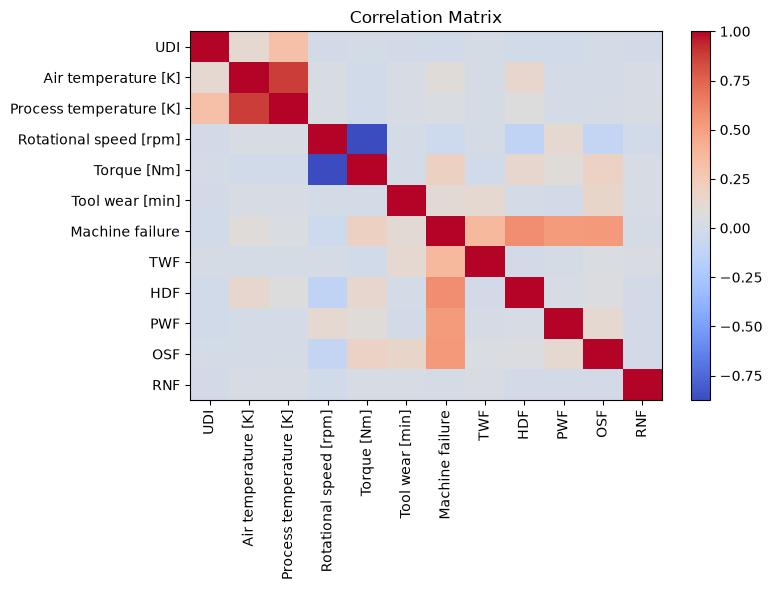

In [21]:
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

The correlation analysis shows that some failure types are strongly related to machine failure, while the main sensor measurements have weaker linear relationships with the target. Air and process temperature are strongly correlated with each other.

### EDA Summary

The dataset contains 10,000 machine records with no missing values. Machine failure is relatively rare, so the target is imbalanced. The main sensor measurements show different relationships with machine failure, while some features are more strongly associated with specific failure types. These observations will be considered during preprocessing and model training.